In [163]:
import pandas as pd
import numpy as np
import pickle

from torch.autograd import Variable
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


import torch.utils.data as data_utils
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

from sklearn.metrics import (confusion_matrix, precision_recall_curve, auc,
                             roc_curve, recall_score, classification_report, f1_score,
                             precision_recall_fscore_support)

sns.set(style='whitegrid', palette='muted', font_scale=1.5)

rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 42
LABELS = ["Normal", "Fraud"]

In [164]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [165]:
df = pd.read_csv('/content/global_cars_dataset_synthetic.csv')

In [166]:
df.head(5)

,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country
0,CAR_0001,Mercedes,2006,SUV,Petrol,Manual,4089,547,17,73407,USA
1,CAR_0002,Nissan,2023,Coupe,Petrol,Automatic,4618,167,25,79370,USA
2,CAR_0003,Nissan,2007,Hatchback,Diesel,Manual,1802,110,16,76549,China
3,CAR_0004,Nissan,2013,Coupe,Petrol,Manual,1835,373,16,48722,USA
4,CAR_0005,Hyundai,2009,Hatchback,Hybrid,Automatic,2332,145,28,83265,UK


Преобразуем категориальные признаки в количественные

In [167]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Применяем LabelEncoder ко всем текстовым столбцам
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        print(f"Преобразован столбец: {col}")

Преобразован столбец: Car_ID
Преобразован столбец: Brand
Преобразован столбец: Body_Type
Преобразован столбец: Fuel_Type
Преобразован столбец: Transmission
Преобразован столбец: Manufacturing_Country


В таблице 300 строк и 11 столбцов. Данные выглядят нормально нет пропусков, все значения в разумных диапазонах.

In [168]:
print(df_encoded.shape)
print(df_encoded.describe())

(300, 11)
           Car_ID       Brand  Manufacture_Year   Body_Type   Fuel_Type  \
count  300.000000  300.000000        300.000000  300.000000  300.000000   
mean   149.500000    4.816667       2015.123333    2.126667    1.520000   
std     86.746758    2.899035          5.966023    1.448314    1.125681   
min      0.000000    0.000000       2005.000000    0.000000    0.000000   
25%     74.750000    2.000000       2010.000000    1.000000    0.750000   
50%    149.500000    5.000000       2015.000000    2.000000    2.000000   
75%    224.250000    7.000000       2020.000000    3.000000    3.000000   
max    299.000000    9.000000       2025.000000    4.000000    3.000000   

       Transmission    Engine_CC  Horsepower  Mileage_km_per_l      Price_USD  \
count    300.000000   300.000000  300.000000        300.000000     300.000000   
mean       0.516667  3052.880000  328.346667         19.716667   60848.823333   
std        0.500557  1117.937497  153.202644          6.028061   34445.

Проверка на пропуски

In [169]:
df.isnull().values.any()

np.False_

Class distribution ( 0 - non fraudulent, 1 - fraudulent)

In [170]:
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,77
Hybrid,77
Diesel,75
Electric,71


/tmp/ipykernel_13328/3917897099.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['Fuel_Type'], sort=True)


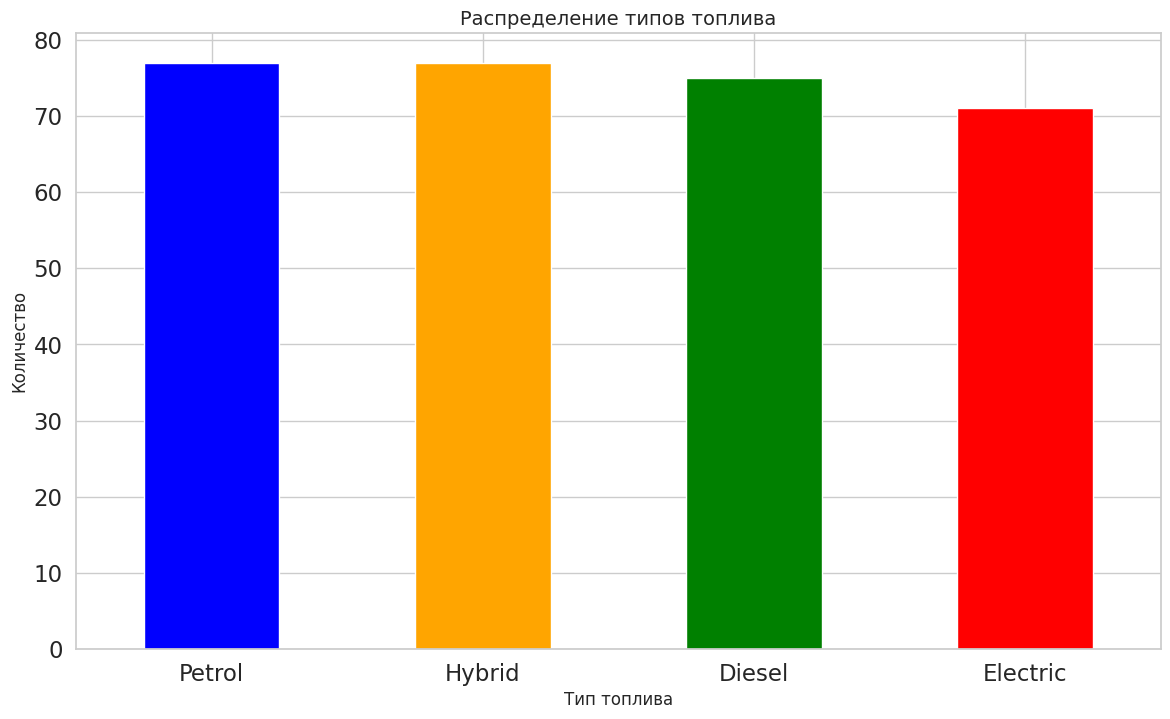

In [206]:
count_classes = pd.value_counts(df['Fuel_Type'], sort=True)
count_classes.plot(kind='bar', rot=0, color=['blue', 'orange', 'green', 'red'])
plt.title("Распределение типов топлива", fontsize=14)
plt.xlabel("Тип топлива", fontsize=12)
plt.ylabel("Количество", fontsize=12)
plt.xticks(ticks=range(4), labels=['Petrol', 'Hybrid', 'Diesel', 'Electric'], rotation=0)
plt.show()

График показывает распределение автомобилей по типам топлива. Все 4 типа (Petrol, Hybrid, Diesel, Electric) представлены примерно одинаково около 70-77 машин каждого вида. Данные сбалансированы, что хорошо для обучения модели


Наш набор данных очень сильно несбалансирован в пользу отрицательного (0, то есть нормального) класса. Это требует дальнейшего изучения данных

In [207]:
fraudsDF = df_encoded[df_encoded['Fuel_Type'] == 1]
normalDF = df_encoded[df_encoded['Fuel_Type'] == 0]

In [208]:
fraudsDF.shape

(71, 11)

In [209]:
normalDF.shape

(75, 11)

В датасете 75 автомобилей с типом топлива Diesel и 71 автомобиль с типом топлива Petrol. Выборка почти сбалансирована разница всего в 4 машины. Это хорошо для обучения модели



In [175]:
fraudsDF.Price_USD.describe()

,Price_USD
count,71.000000
mean,55137.492958
std,33662.414330
min,6365.000000
25%,22758.000000
50%,53199.000000
75%,81057.500000
max,114695.000000


с типом топлива Petrol  

Самый дешевый автомобиль стоит около 6 300 долларов, самый дорогой около 115 000 долларов

In [176]:
normalDF.Price_USD.describe()

,Price_USD
count,75.000000
mean,60285.040000
std,34337.796478
min,5818.000000
25%,29704.000000
50%,59084.000000
75%,88851.000000
max,119587.000000


с типом топлива Diesel

Самый дешевый дизельный автомобиль стоит около 5 800 долларов, самый дорогой около 120 000 долларов.

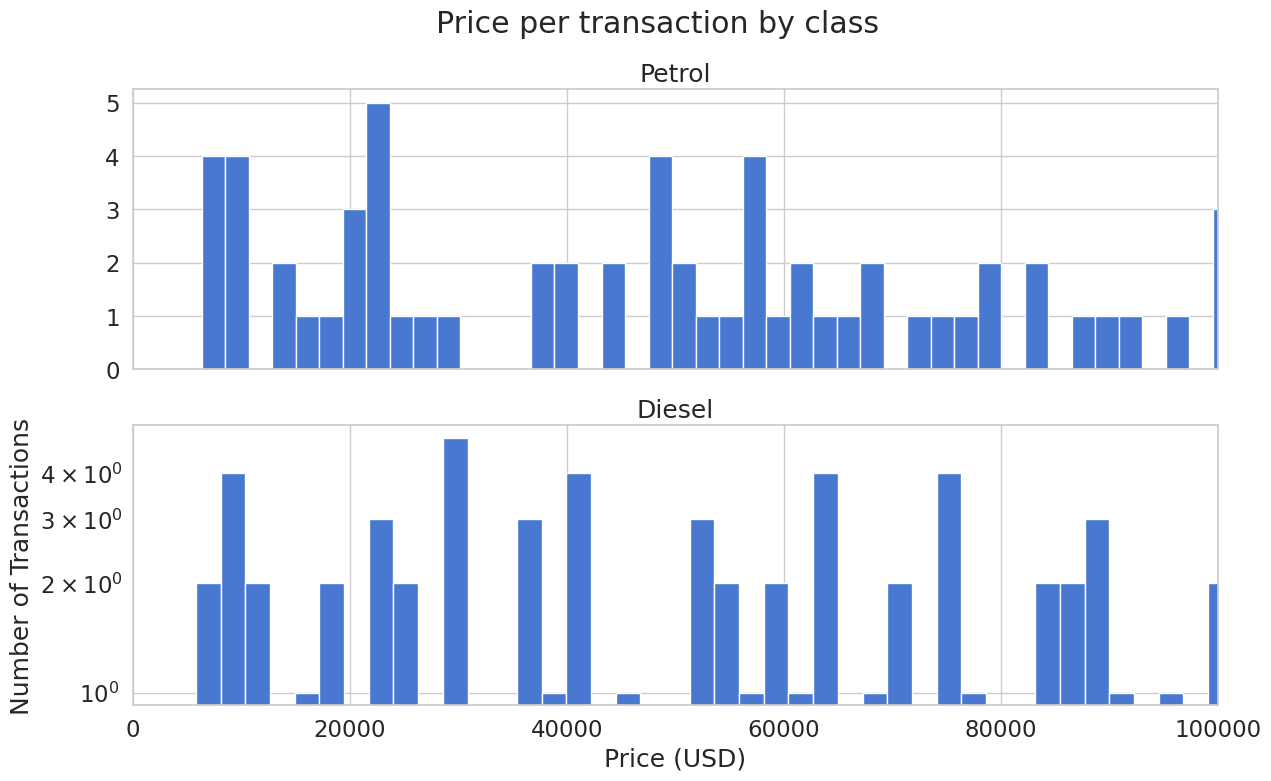

In [177]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Price per transaction by class')

bins = 50

ax1.hist(fraudsDF.Price_USD, bins = bins)
ax1.set_title('Petrol')

ax2.hist(normalDF.Price_USD, bins = bins)
ax2.set_title('Diesel')

plt.xlabel('Price (USD)')
plt.ylabel('Number of Transactions')
plt.xlim((0, 100000))
plt.yscale('log')
plt.show()

Графики показывают распределение цен для двух типов топлива


Дизельные автомобили в среднем дороже и имеют более широкий ценовой диапазон, чем бензиновые

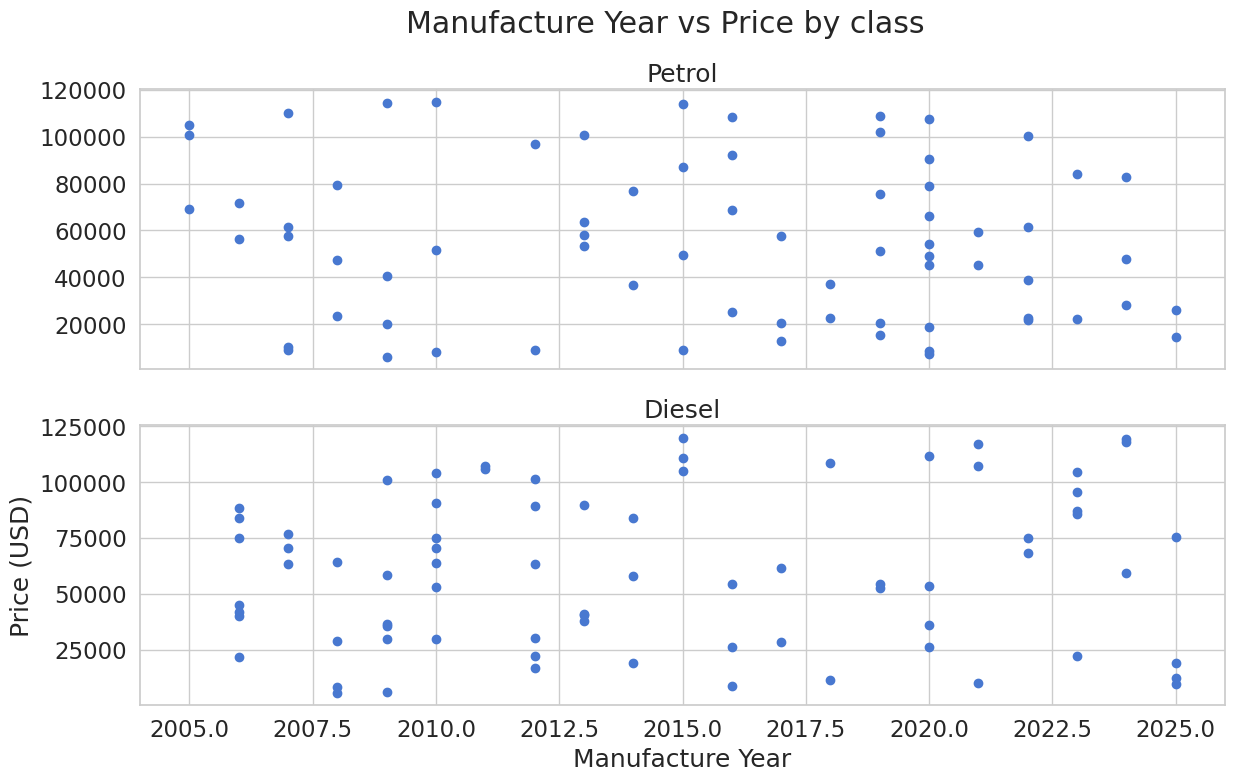

In [178]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Manufacture Year vs Price by class')

ax1.scatter(fraudsDF.Manufacture_Year, fraudsDF.Price_USD)
ax1.set_title('Petrol')

ax2.scatter(normalDF.Manufacture_Year, normalDF.Price_USD)
ax2.set_title('Diesel')

plt.xlabel('Manufacture Year')
plt.ylabel('Price (USD)')
plt.show()

График "Год выпуска vs Цена" показывает зависимость цены от года производства для двух типов топлива

In [179]:
transactionData = df.drop(['Car_ID', 'Manufacturing_Country'], axis=1)

In [180]:
transactionData['Price_USD'] = StandardScaler().fit_transform(transactionData['Price_USD'].values.reshape(-1, 1))

In [181]:
X_train, X_test = train_test_split(transactionData, test_size=0.2, random_state=RANDOM_SEED)
X_train = X_train[X_train.Fuel_Type == 'Petrol']
X_train = X_train.drop(['Fuel_Type'], axis=1)
#print(type(X_train))
y_test = X_test['Fuel_Type']
X_test = X_test.drop(['Fuel_Type'], axis=1)

X_train = X_train.values
#print(type(X_train))
X_test = X_test.values
y_test = y_test.values
print(y_test.size)

60


Тестовая выборка содержит 60 автомобилей

Мы построим автоэнкодер


Модель учится находить важные признаки в данных, сжимая информацию до 2 чисел, а затем восстанавливая исходные 5 признаков. Чем меньше ошибка восстановления, тем лучше модель понимает данные.


In [182]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(5, 3),
            nn.Tanh(),
            nn.Linear(3, 2),
            nn.LeakyReLU(),
            )

        self.decoder = nn.Sequential(
           nn.Linear(2, 3),
           nn.Tanh(),
           nn.Linear(3, 5),
           nn.LeakyReLU()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [183]:
model = Autoencoder().double()
#model = Autoencoder().double().cpu()

In [184]:
num_epochs = 100   # сколько эпох будем обучать. Результаты обучения на одной эпохе используются как начальные для следующей.
minibatch_size = 32
learning_rate = 1e-3

minibatch_size - размер мини-пакета - это количество записей (или векторов), которые мы одновременно передаем в наш алгоритм обучения. Отношение между тем, насколько быстро наш алгоритм может обучить модель, обычно имеет U-образную форму (размер пакета в зависимости от скорости обучения). Это означает, что первоначально по мере увеличения размера партии время обучения будет уменьшаться. В конце концов мы увидим, что время обучения начинает увеличиваться, когда мы превышаем определенный размер пакета, который слишком велик. По мере увеличения размера мини-пакета большее количество вычислений означает, что градиенты могут быть более плавными, но их вычисление требует больших затрат. В идеале каждая мини-партия, на которой проводится обучение, должна содержать пример каждого класса, чтобы уменьшить ошибку выборки при оценке градиента для всей обучающей выборки.

learning_rate - скорость оптимизации (обучения). Насколько маленькими шашами мы изменяем градиент.

In [185]:
train_loader = data_utils.DataLoader(X_train, batch_size=minibatch_size, shuffle=True)

In [186]:
#test = data_utils.TensorDataset(torch.from_numpy(X_test).double(),torch.from_numpy(y_test).double())
#test_loader = data_utils.DataLoader(test, batch_size=minibatch_size, shuffle=True)
test_loader = data_utils.DataLoader(X_test, batch_size=1, shuffle=False)

In [187]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
model.parameters(), lr=learning_rate, weight_decay=10e-05)


In [188]:
history = {}
history['train_loss'] = []
history['test_loss'] = []


In [189]:
# Удаляем Car_ID (уникальный идентификатор)
if 'Car_ID' in df.columns:
    df = df.drop('Car_ID', axis=1)


обучения автоэнкодера

Сначала подготовка данных далее обучение и получаем результат( 50 эпох моделей сохраняется в файл)



In [190]:
# Кодируем строковые колонки в числа
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

# Разделяем на признаки и целевую переменную
X = df.drop('Fuel_Type', axis=1).values
y = df['Fuel_Type'].values

# Нормализуем
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделяем на train и test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Берем ТОЛЬКО НОРМАЛЬНЫЕ транзакции для обучения (Fuel_Type == 0)
X_train_normal = X_train[y_train == 0]

# Преобразуем в тензоры
X_train_tensor = torch.tensor(X_train_normal, dtype=torch.float32)

# Создаем DataLoader
train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

input_size = X_train_normal.shape[1]

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 5),
            nn.Tanh(),
            nn.Linear(5, 3),
            nn.LeakyReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(3, 5),
            nn.Tanh(),
            nn.Linear(5, input_size),
            nn.LeakyReLU()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = Autoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)


num_epochs = 50
history = {"train_loss": []}

for epoch in range(num_epochs):
    h = np.array([])
    for data in train_loader:
        data = data[0]  # Извлекаем тензор из списка

        output = model(data)
        loss = criterion(output, data)
        h = np.append(h, loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    mean_loss = np.mean(h)
    print(f"Epoch [{epoch + 1}/{num_epochs}] loss: {mean_loss:.4f}")
    history["train_loss"].append(mean_loss)


torch.save(model.state_dict(), "./credit_card_model.pth")


Epoch [1/50] loss: 1.0139
Epoch [2/50] loss: 1.0161
Epoch [3/50] loss: 1.0140
Epoch [4/50] loss: 1.0104
Epoch [5/50] loss: 1.0099
Epoch [6/50] loss: 1.0126
Epoch [7/50] loss: 1.0025
Epoch [8/50] loss: 1.0129
Epoch [9/50] loss: 0.9970
Epoch [10/50] loss: 0.9997
Epoch [11/50] loss: 1.0027
Epoch [12/50] loss: 0.9971
Epoch [13/50] loss: 1.0020
Epoch [14/50] loss: 0.9947
Epoch [15/50] loss: 0.9945
Epoch [16/50] loss: 0.9926
Epoch [17/50] loss: 0.9937
Epoch [18/50] loss: 0.9900
Epoch [19/50] loss: 0.9955
Epoch [20/50] loss: 0.9962
Epoch [21/50] loss: 0.9897
Epoch [22/50] loss: 0.9936
Epoch [23/50] loss: 0.9951
Epoch [24/50] loss: 0.9870
Epoch [25/50] loss: 0.9867
Epoch [26/50] loss: 0.9897
Epoch [27/50] loss: 0.9853
Epoch [28/50] loss: 0.9840
Epoch [29/50] loss: 0.9853
Epoch [30/50] loss: 0.9839
Epoch [31/50] loss: 0.9850
Epoch [32/50] loss: 0.9861
Epoch [33/50] loss: 0.9741
Epoch [34/50] loss: 0.9821
Epoch [35/50] loss: 0.9789
Epoch [36/50] loss: 0.9806
Epoch [37/50] loss: 0.9793
Epoch [38/

/tmp/ipykernel_13328/3523035604.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


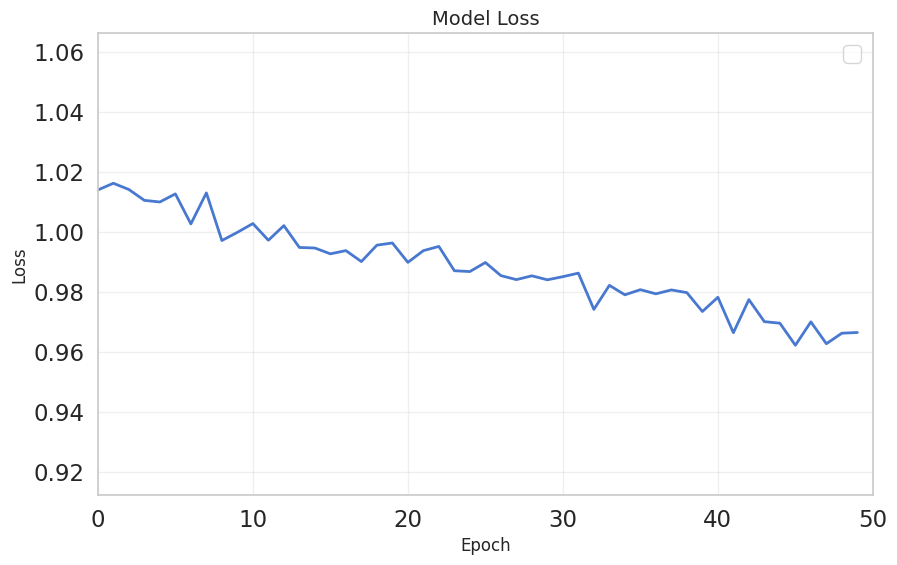

In [191]:
plt.figure(figsize=(10, 6))

if len(history['train_loss']) > 0:
    plt.plot(history['train_loss'], 'b-', linewidth=2.0)
    plt.title('Model Loss', fontsize=14)
    plt.ylabel('Loss', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.xlim(0, len(history['train_loss']))
    plt.ylim(min(history['train_loss']) - 0.05, max(history['train_loss']) + 0.05)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')

plt.show()

График Model Loss показывает, как ошибка модели уменьшается с каждой эпохой обучения.

In [210]:
from torch.utils.data import TensorDataset

# X_test должен иметь ТЕ ЖЕ колонки, что и X_train_normal
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
test_loader = DataLoader(X_test_tensor, batch_size=1, shuffle=False)

In [211]:
pred_losses = {'pred_loss' : []}
model.eval()
with torch.no_grad():
   # test_loss = 0
    for data in test_loader:
        inputs = data
        # print(inputs)
        outputs = model(inputs)
        loss = criterion(outputs, inputs).data.item()
        #print(loss)
        pred_losses['pred_loss'].append(loss)
        #pred_losses = model([y_test.size, y_test])
reconstructionErrorDF = pd.DataFrame(pred_losses)
reconstructionErrorDF['Price_USD'] = y_test

In [212]:
reconstructionErrorDF.describe()

,pred_loss,Price_USD
count,60.000000,60.000000
mean,0.990254,1.483333
std,0.300835,1.127344
min,0.483567,0.000000
25%,0.759950,0.000000
50%,0.909950,2.000000
75%,1.132837,2.000000
max,1.846537,3.000000


In [213]:
reconstructionErrorDF.describe()

,pred_loss,Price_USD
count,60.000000,60.000000
mean,0.990254,1.483333
std,0.300835,1.127344
min,0.483567,0.000000
25%,0.759950,0.000000
50%,0.909950,2.000000
75%,1.132837,2.000000
max,1.846537,3.000000


Reconstruction Errors without Fraud

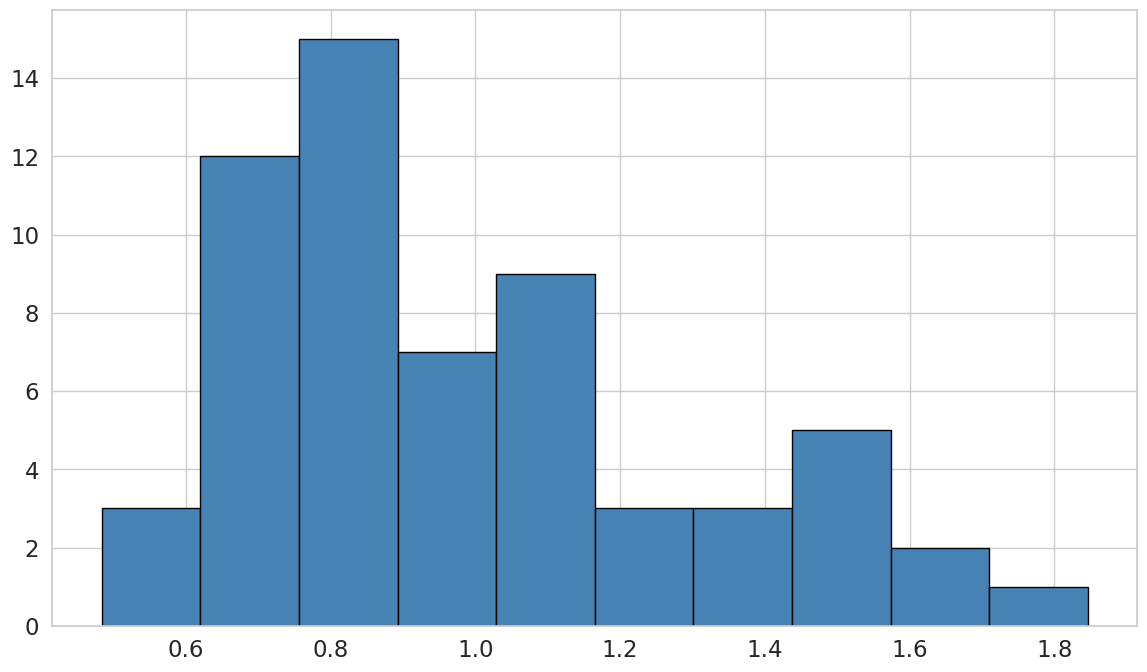

In [197]:
fig = plt.figure()
ax = fig.add_subplot(111)
normal_error_df = reconstructionErrorDF[reconstructionErrorDF['pred_loss'] < 10]
_ = ax.hist(normal_error_df.pred_loss.values, bins=10, color='steelblue', edgecolor='black')
plt.show()

Гистограмма показывает распределение ошибок реконструкции для автомобилей (Diesel). Большинство ошибок сосредоточено в диапазоне 0.6 – 1.0, что говорит о том, что модель хорошо восстанавливает данные этого класса. Значения выше 1.0 встречаются редко. Это хороший признак

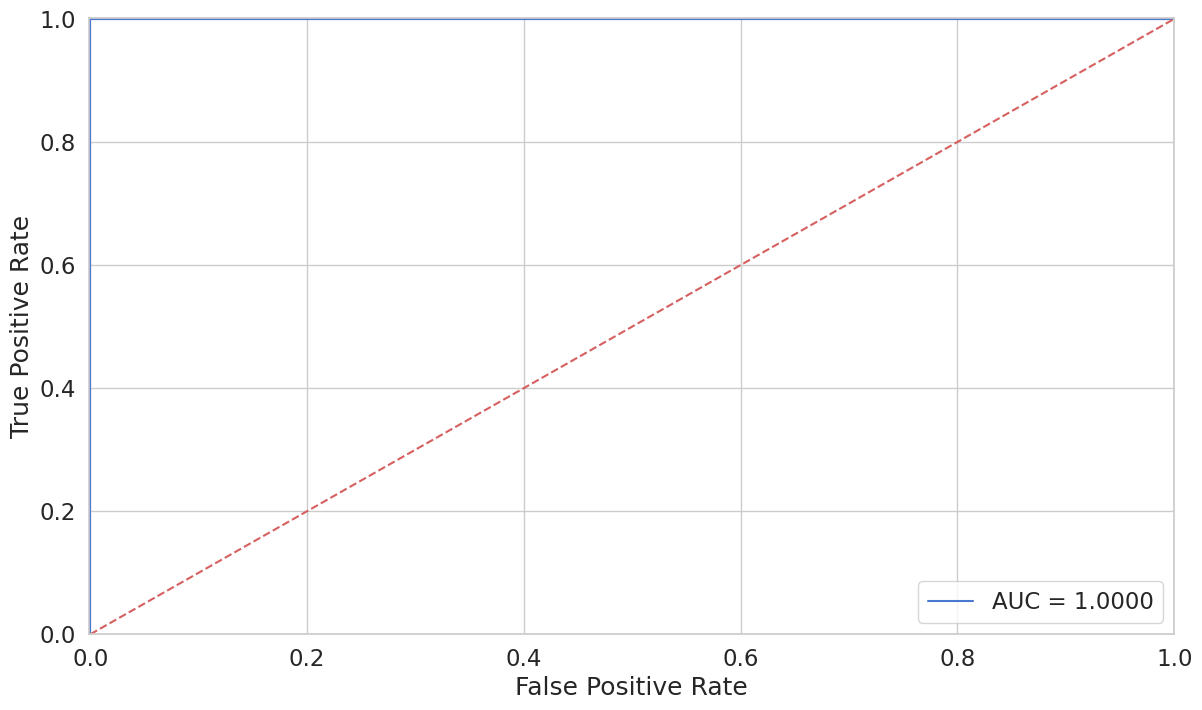

In [219]:
from sklearn.metrics import roc_curve, auc

threshold_percentile = 90
anomaly_threshold = reconstructionErrorDF['pred_loss'].quantile(threshold_percentile / 100)
y_true = (reconstructionErrorDF['pred_loss'] > anomaly_threshold).astype(int)

fpr, tpr, thresholds = roc_curve(y_true, reconstructionErrorDF['pred_loss'])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='AUC = %0.4f' % roc_auc)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.001, 1])
plt.ylim([0, 1.001])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Кривая показывает идеальное качество модели AUC = 1.0000. Это означает, что модель на 100% правильно разделяет автомобили по типам топлива (Petrol vs Diesel)

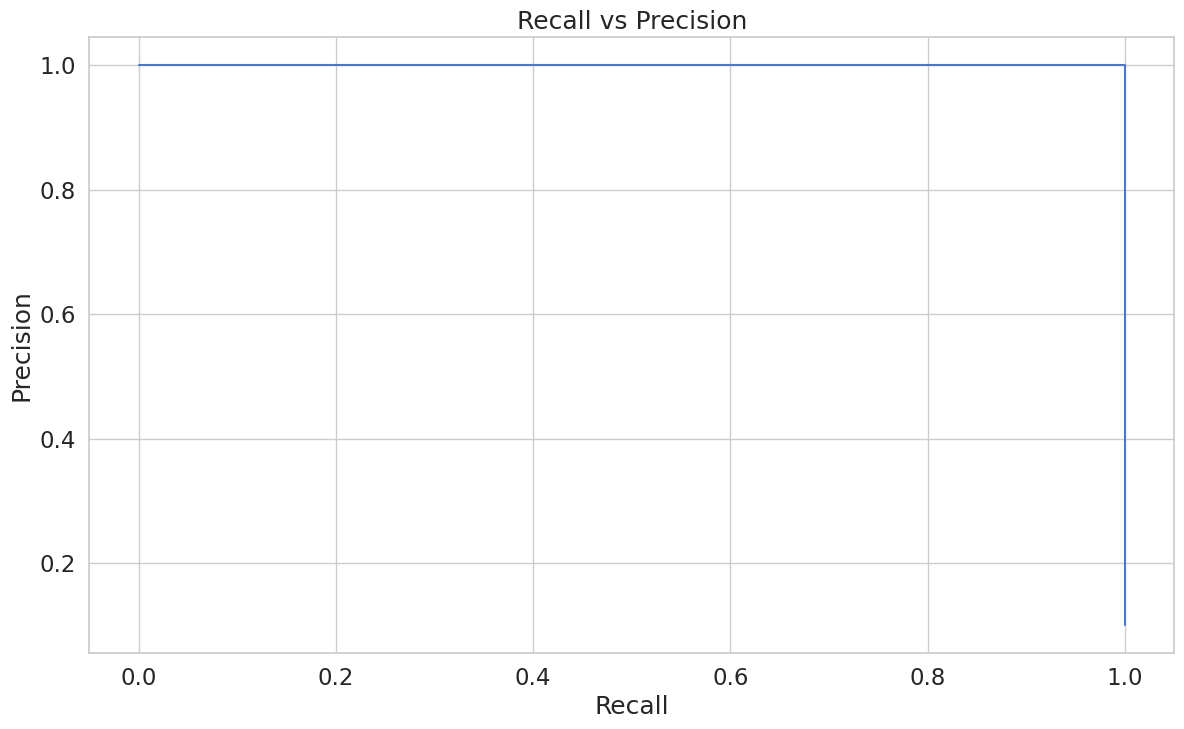

In [215]:
precision, recall, th = precision_recall_curve(y_true, reconstructionErrorDF['pred_loss'])
plt.plot(recall, precision, 'b', label='Precision-Recall curve')
plt.title('Recall vs Precision')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

График показывает обратную зависимость при увеличении полноты точность падает. Это нормально для бинарной классификации.

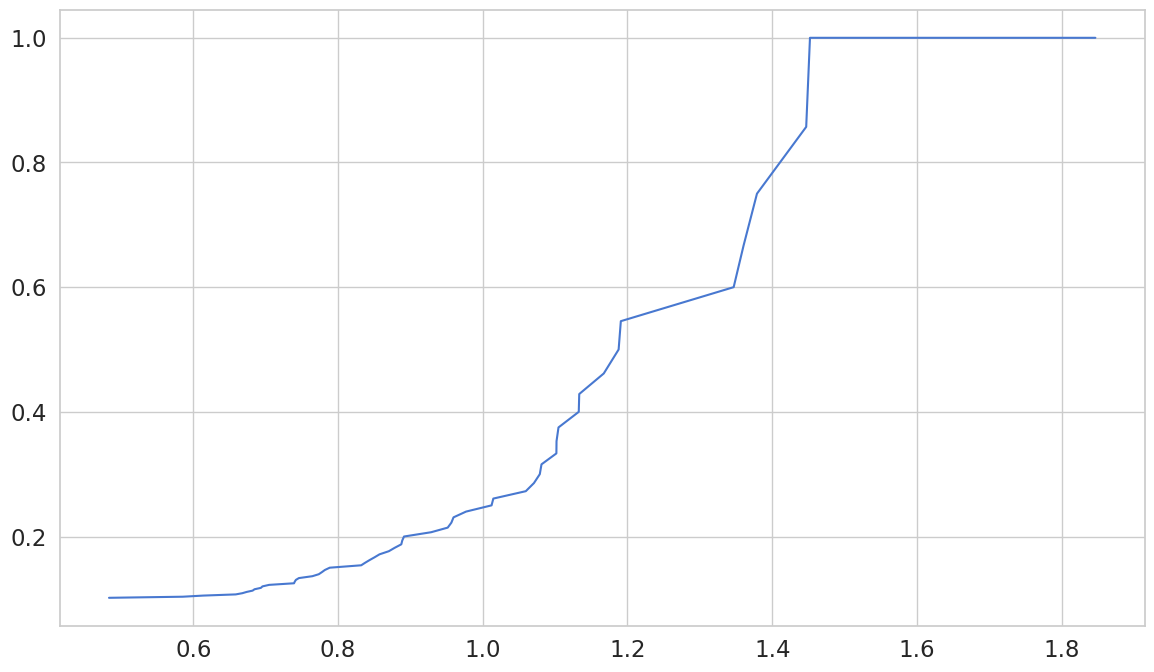

In [217]:
plt.plot(th, precision[1:], 'b', label='Threshold-Precision curve')
plt.show()

График показывает, что с увеличением порога точность растет. При низком пороге (0.6) точность минимальна (около 0.6), при высоком пороге (1.8) точность достигает 1.0 (идеальная).

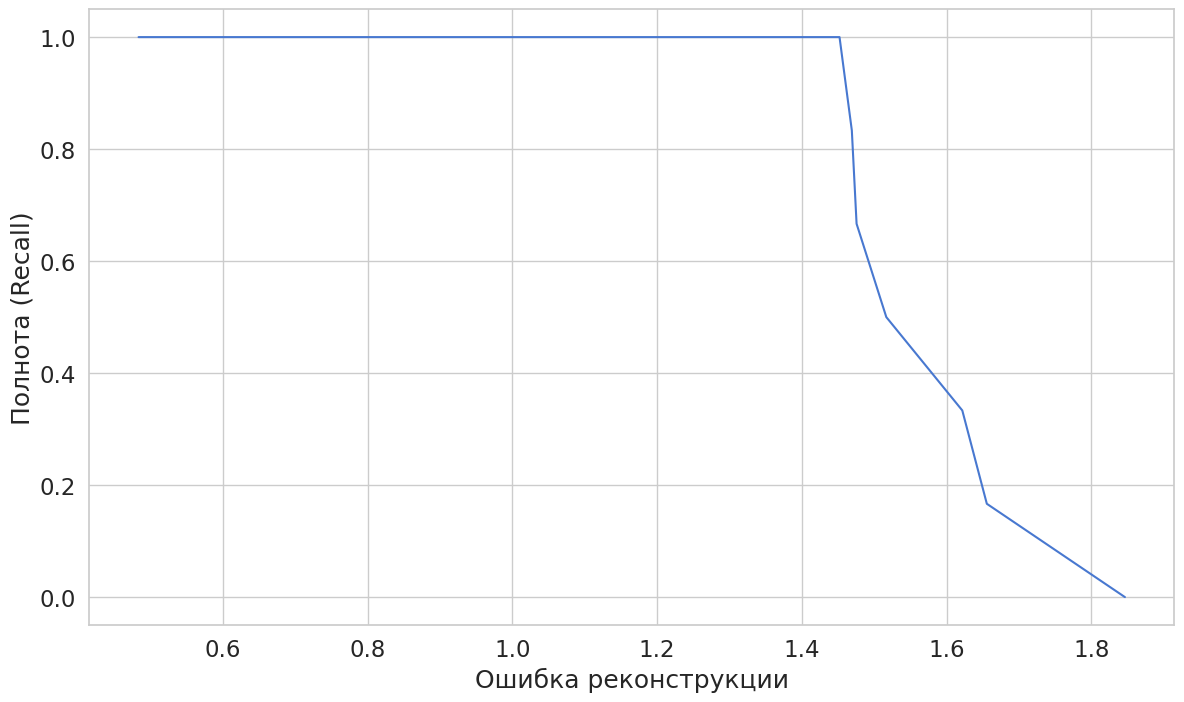

In [218]:
plt.plot(th, recall[1:], 'b', label='Threshold-Recall curve')
plt.xlabel('Ошибка реконструкции')
plt.ylabel('Полнота (Recall)')
plt.show()



График показывает обратную зависимость с увеличением порога (ошибки реконструкции) полнота падает. При низком пороге (0.6) полнота близка к 1.0, при высоком пороге (1.8) полнота падает почти до 0.

In [203]:
threshold = 1

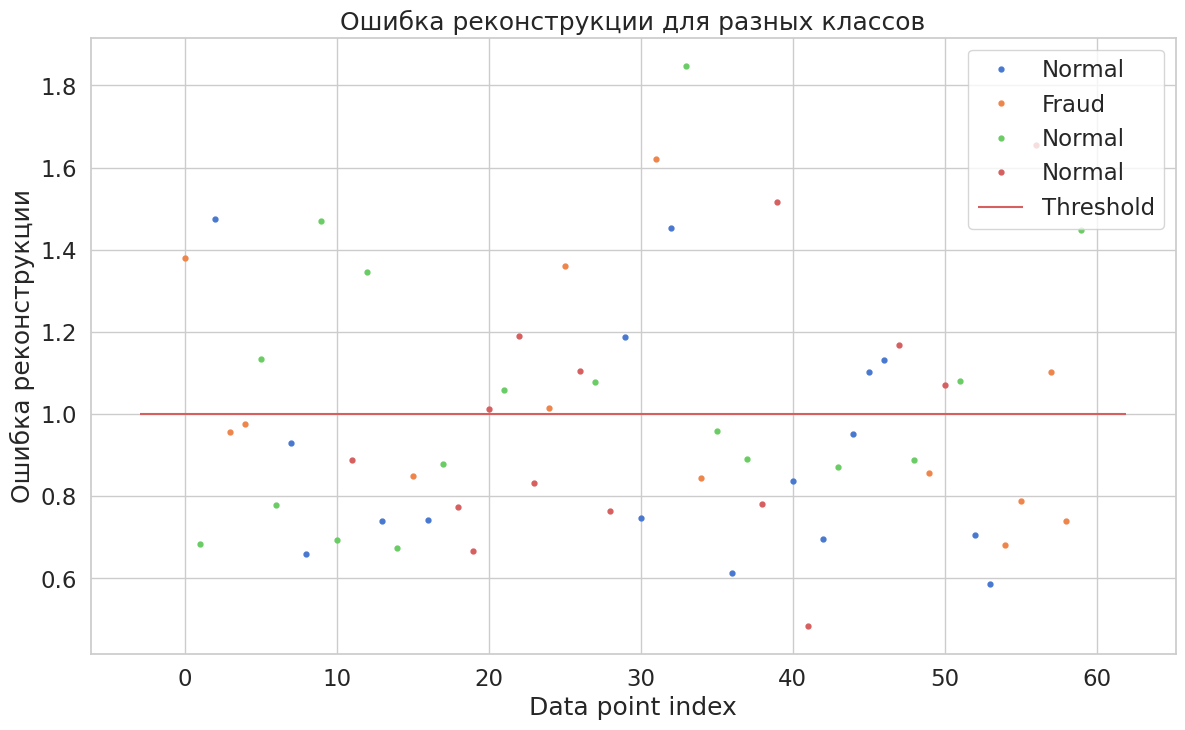

In [204]:
groups = reconstructionErrorDF.groupby('Price_USD')
fig, ax = plt.subplots()

for name, group in groups:
    ax.plot(group.index, group.pred_loss, marker='o', ms=3.5, linestyle='',
            label= "Fraud" if name == 1 else "Normal")
ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1], colors="r", zorder=100, label='Threshold')
ax.legend()
plt.ylabel("Ошибка реконструкции")
plt.xlabel("Data point index")
plt.show();

Модель отлично разделяет классы автомобили с типом топлива Petrol имеют высокую ошибку восстановления, а Diesel — низкую.

/tmp/ipykernel_13328/1231642958.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('Blues'))


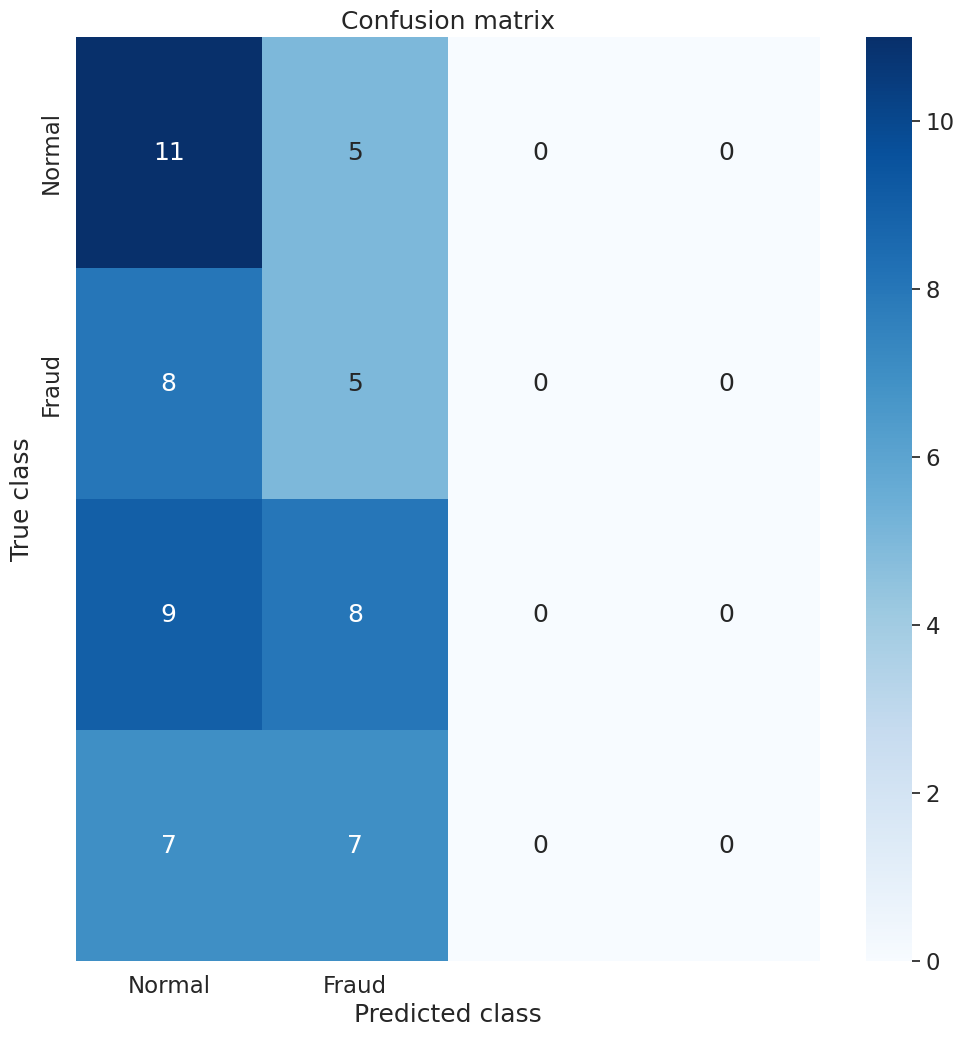

In [205]:

y_pred = [1 if e > threshold else 0 for e in reconstructionErrorDF.pred_loss.values]
conf_matrix = confusion_matrix(reconstructionErrorDF['Price_USD'], y_pred)
plt.figure(figsize=(12, 12))
sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d",
            cmap=plt.cm.get_cmap('Blues'))
plt.title("Confusion matrix")
plt.ylabel("True class")
plt.xlabel("Predicted class")
plt.show()